In [7]:
#import relevant libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from collections import defaultdict
from matplotlib.patches import Circle
import matplotlib.font_manager as fm
import dabest

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 14.51it/s]

Numba compilation complete!


In [8]:
#initial file processing

workcomp = "C:\\Users\\User"
laptop = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
specifiedpath = homecomp

filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Cell stainings\\"
brainvol = "ACR1 eOPN3 MB Area.xlsx"     

df_bv= pd.read_excel(specifiedpath + filedir + brainvol)

# Set up Inter font
inter_font_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Regular.ttf"
inter_bold_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Bold.ttf"
inter_italic_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Italic.ttf"

# Register fonts
import matplotlib.font_manager as fm
fm.fontManager.addfont(inter_font_path)
fm.fontManager.addfont(inter_bold_path)
fm.fontManager.addfont(inter_italic_path)

# Set Inter as default font
plt.rcParams['font.family'] = 'Inter'

In [9]:
df_bv

,Genotype,Position,Mean,Area
0,ACR1,Anterior,138.904,27996.220
1,ACR1,Anterior,114.003,24452.316
2,ACR1,Anterior,61.478,24827.317
3,ACR1,Anterior,62.275,29050.912
4,ACR1,Anterior,211.605,27652.238
5,ACR1,Anterior,116.303,27520.574
6,ACR1,Anterior,87.014,16302.233
7,ACR1,Anterior,115.954,28638.686
8,eOPN3,Anterior,167.731,4276.846
9,eOPN3,Anterior,122.894,2970.544


In [14]:
df1  = df_bv.replace({"ACR1": "GtACR1", "eOPN3": "AsOPN3"}, regex=True)
df1["Genotype_Position"] = df1["Genotype"] + " " + df1["Position"]

paired_delta2 = dabest.load(data = df1, idx = ("GtACR1", "AsOPN3"), x="Genotype", y="Area")

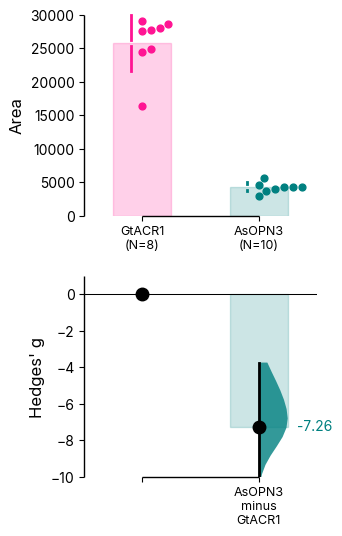

In [22]:
palette = { 'GtACR1':'deeppink', 'AsOPN3' : 'teal'}
genoListNL = ['GtACR1','AsOPN3']

compare = paired_delta2.hedges_g.plot(fontsize_rawxlabel=9,fontsize_contrastxlabel= 9, raw_ylim=(0,30000), contrast_ylim=(-10,1), float_contrast=False,
                                       custom_palette=palette,  raw_desat=1, contrast_desat=1);

  
mpl.rcParams['svg.fonttype'] = 'none' 
plt.show()
#compare.savefig(specifiedpath + filedir + "posterioranterior_sum.svg")
#compare.savefig('MB247ACR1 eOPN3.png', dpi = 300)
#compare.savefig('MB247ACR1 eOPN3.svg')
